<a href="https://colab.research.google.com/github/Samay-Kochhar/decision-analytics/blob/main/decision_analytics_serieA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# --- 1.  paths to your two files ---------------------------------
csv_1 = "/content/SerieA_2014-2019.csv"
csv_2 = "/content/SerieA_2019-2024.csv"

# --- 2.  read them ------------------------------------------------
df1 = pd.read_csv(csv_1)
df2 = pd.read_csv(csv_2)

# --- 3.  parse Date → datetime, derive Season ---------------------
for df in (df1, df2):
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
    df["Season"] = df["Date"].dt.year.where(df["Date"].dt.month >= 7,
                                            df["Date"].dt.year - 1)

# --- 4.  append / concatenate ------------------------------------
df = pd.concat([df1, df2], ignore_index=True)

# --- 5.  sort & give each row a unique MatchID -------------------
df = (df.sort_values(["Season", "Date", "HomeTeam", "AwayTeam"])
        .reset_index(drop=True))
df["MatchID"] = df.index + 1

print("Combined rows:", len(df))
print("Seasons:", sorted(df["Season"].unique()))
df

Combined rows: 3800
Seasons: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023)]


/tmp/ipython-input-1-451236363.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)


,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,MatchID
0,I1,2014-08-30,Chievo,Juventus,0,1,A,0.0,1.0,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,I1,2014-08-30,Roma,Fiorentina,2,0,H,1.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
2,I1,2014-08-31,Atalanta,Verona,0,0,D,0.0,0.0,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
3,I1,2014-08-31,Cesena,Parma,1,0,H,1.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
4,I1,2014-08-31,Genoa,Napoli,1,2,A,1.0,1.0,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3795,I1,2024-05-26,Frosinone,Udinese,0,1,A,0.0,0.0,D,...,-0.25,2.13,1.81,2.22,1.74,2.22,1.83,2.11,1.76,3796
3796,I1,2024-05-26,Lazio,Sassuolo,1,1,D,0.0,0.0,D,...,-1.50,1.99,1.94,1.99,1.93,2.02,2.00,1.93,1.93,3797
3797,I1,2024-05-26,Napoli,Lecce,0,0,D,0.0,0.0,D,...,-1.50,2.03,1.90,2.03,1.89,2.04,1.92,1.98,1.87,3798
3798,I1,2024-05-26,Verona,Inter,2,2,D,2.0,2.0,D,...,1.25,2.05,1.88,2.07,1.86,2.07,1.97,1.98,1.87,3799


In [ ]:
# three clubs you found that are NOT part of the 20-club Serie A for 2020/21
extra_2020 = {"Brescia", "Lecce", "Spal"}

mask_keep = ~(
    (df["Season"] == 2020) &          # 2020 start-year ➜ 2020/21 season
    (df["HomeTeam"].isin(extra_2020) | df["AwayTeam"].isin(extra_2020))
)

df = df.loc[mask_keep].reset_index(drop=True)
print("Rows after dropping extras:", len(df))

Rows after dropping extras: 3772


In [ ]:
def add_matchday(group):
    # Serie A: 20 clubs → 10 matches per round
    mpr = 10
    group = group.sort_values("Date").reset_index(drop=True)
    group["Matchday"] = group.index // mpr + 1
    return group

df = df.groupby("Season", group_keys=False).apply(add_matchday)

# quick verification
print(df.groupby("Season")["Matchday"].agg(["min","max"]).loc[2020])
# should show 1 … 38

min     1
max    45
Name: 2020, dtype: int64


/tmp/ipython-input-3-392197314.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Season", group_keys=False).apply(add_matchday)


In [ ]:
# ------------------------------------------------------------
# 1) keep only true Serie-A fixtures
#    • Division must be I1
#    • exactly one copy of each (Date, Home, Away)
# ------------------------------------------------------------
df = df[df["Div"] == "I1"].copy()          # drops any Coppa rounds
print("Rows after Div filter:", len(df))

# deduplicate by the unique match key
dupe_mask = df.duplicated(["Season","Date","HomeTeam","AwayTeam"], keep="first")
print("Duplicate rows removed:", dupe_mask.sum())
df = df.loc[~dupe_mask].reset_index(drop=True)

# ------------------------------------------------------------
# 2) count rows per 2020 season  → should be 380 now
# ------------------------------------------------------------
rows_2020 = len(df[df["Season"] == 2020])
print("Rows in 2020/21 after cleanup:", rows_2020)  # expect 380

# ------------------------------------------------------------
# 3) stamp the match-day properly (10 games per round)
# ------------------------------------------------------------
def add_matchday(g):
    mpr = len(set(g["HomeTeam"]).union(g["AwayTeam"])) // 2  # 20→10
    g   = g.sort_values("Date").reset_index(drop=True)
    g["Matchday"] = g.index // mpr + 1
    return g

df = df.groupby("Season", group_keys=False).apply(add_matchday)

print(df.groupby("Season")["Matchday"].agg(["min","max"]).loc[2020])
#  → min 1 , max 38

Rows after Div filter: 3772
Duplicate rows removed: 0
Rows in 2020/21 after cleanup: 450
min     1
max    45
Name: 2020, dtype: int64


/tmp/ipython-input-4-1725835597.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Season", group_keys=False).apply(add_matchday)


In [ ]:
# 1)  remove duplicate league fixtures (same season-home-away)
dupe_mask = df.duplicated(["Season", "HomeTeam", "AwayTeam"], keep="first")
print("Duplicate rows removed by Home/Away pair:", dupe_mask.sum())

df = df.loc[~dupe_mask].reset_index(drop=True)

# 2)  verify 2020/21 now has exactly 380 rows
rows_2020 = len(df[df["Season"] == 2020])
print("Rows in 2020/21 after pair-dedup:", rows_2020)   # should print 380

# 3)  re-stamp the match-day column
def add_matchday(g):
    mpr = len(set(g["HomeTeam"]).union(g["AwayTeam"])) // 2   # 20→10
    g   = g.sort_values("Date").reset_index(drop=True)
    g["Matchday"] = g.index // mpr + 1
    return g

df = df.groupby("Season", group_keys=False).apply(add_matchday)

print(df.groupby("Season")["Matchday"].agg(["min","max"]).loc[2020])
# -> min 1 , max 38

Duplicate rows removed by Home/Away pair: 70
Rows in 2020/21 after pair-dedup: 380
min     1
max    38
Name: 2020, dtype: int64


/tmp/ipython-input-5-1366337415.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Season", group_keys=False).apply(add_matchday)


In [ ]:
# ─── Stamp the true Match-day BEFORE any rows are removed ─────────
def add_matchday(group):
    # Serie A has 20 clubs → 10 matches per round
    matches_per_round = 10
    # keep each season in chronological order
    group = group.sort_values("Date").reset_index(drop=True)
    # integer-divide the running row index by matches_per_round
    group["Matchday"] = group.index // matches_per_round + 1
    return group

# apply season-by-season
df = df.groupby("Season", group_keys=False).apply(add_matchday)
df

/tmp/ipython-input-6-2047477953.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Season", group_keys=False).apply(add_matchday)


,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,MatchID,Matchday
0,I1,2014-08-30,Chievo,Juventus,0,1,A,0.0,1.0,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
1,I1,2014-08-30,Roma,Fiorentina,2,0,H,1.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1
2,I1,2014-08-31,Atalanta,Verona,0,0,D,0.0,0.0,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,1
3,I1,2014-08-31,Cesena,Parma,1,0,H,1.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,1
4,I1,2014-08-31,Genoa,Napoli,1,2,A,1.0,1.0,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,I1,2024-05-26,Frosinone,Udinese,0,1,A,0.0,0.0,D,...,2.13,1.81,2.22,1.74,2.22,1.83,2.11,1.76,3796,38
376,I1,2024-05-26,Lazio,Sassuolo,1,1,D,0.0,0.0,D,...,1.99,1.94,1.99,1.93,2.02,2.00,1.93,1.93,3797,38
377,I1,2024-05-26,Napoli,Lecce,0,0,D,0.0,0.0,D,...,2.03,1.90,2.03,1.89,2.04,1.92,1.98,1.87,3798,38
378,I1,2024-05-26,Verona,Inter,2,2,D,2.0,2.0,D,...,2.05,1.88,2.07,1.86,2.07,1.97,1.98,1.87,3799,38


In [ ]:
# print(df["Matchday"].value_counts().sort_index())

In [ ]:
#team names in each season

for yr in sorted(df["Season"].unique()):
    clubs = sorted(set(df.loc[df["Season"] == yr, "HomeTeam"]))
    print(f"\nSeason {yr}/{yr+1}:")
    print(", ".join(clubs))


Season 2014/2015:
Atalanta, Cagliari, Cesena, Chievo, Empoli, Fiorentina, Genoa, Inter, Juventus, Lazio, Milan, Napoli, Palermo, Parma, Roma, Sampdoria, Sassuolo, Torino, Udinese, Verona

Season 2015/2016:
Atalanta, Bologna, Carpi, Chievo, Empoli, Fiorentina, Frosinone, Genoa, Inter, Juventus, Lazio, Milan, Napoli, Palermo, Roma, Sampdoria, Sassuolo, Torino, Udinese, Verona

Season 2016/2017:
Atalanta, Bologna, Cagliari, Chievo, Crotone, Empoli, Fiorentina, Genoa, Inter, Juventus, Lazio, Milan, Napoli, Palermo, Pescara, Roma, Sampdoria, Sassuolo, Torino, Udinese

Season 2017/2018:
Atalanta, Benevento, Bologna, Cagliari, Chievo, Crotone, Fiorentina, Genoa, Inter, Juventus, Lazio, Milan, Napoli, Roma, Sampdoria, Sassuolo, Spal, Torino, Udinese, Verona

Season 2018/2019:
Atalanta, Bologna, Cagliari, Chievo, Empoli, Fiorentina, Frosinone, Genoa, Inter, Juventus, Lazio, Milan, Napoli, Parma, Roma, Sampdoria, Sassuolo, Spal, Torino, Udinese

Season 2019/2020:
Atalanta, Bologna, Brescia, Cag

In [ ]:
#details of the matches played between the promoted teams, in next step these rows will be removed.
promoted_D1 = {
    2014: {"Palermo", "Empoli"},          # season 2018/19
    2015: {"Carpi", "Frosinone"},
    2016: {"Cagliari", "Crotone"},
    2017: {"Spal", "Verona"},
    2018: {"Parma", "Empoli"},
    2019: {"Brescia", "Lecce"},          # season 2019/20
    2020: {"Benevento", "Crotone"},        # 2020/21
    2021: {"Empoli", "Salernitana"},      # 2021/22
    2022: {"Cremonese", "Lecce"},   # 2022/23
    2023: {"Frosinone", "Genoa"},       # 2023/24
}

# select and in next step delete the rows when mathc is between two promoted teams
mask_promoted_pair = df.apply(
    lambda r: r["Div"] == "I1"
           and r["HomeTeam"] in promoted_D1.get(r["Season"], set())
           and r["AwayTeam"] in promoted_D1.get(r["Season"], set()),
    axis=1
)

# to see which matches will be removed so to check basically
promoted_vs_promoted = df.loc[mask_promoted_pair,
                              ["Date", "Season", "HomeTeam", "AwayTeam"] \
                              + [col for col in df.columns if col not in
                                 {"Date","Season","HomeTeam","AwayTeam"}]]

print(f"{len(promoted_vs_promoted)} promoted-vs-promoted fixtures:")
print(promoted_vs_promoted.to_string(index=False))

19 promoted-vs-promoted fixtures:
      Date  Season    HomeTeam    AwayTeam Div  FTHG  FTAG FTR  HTHG  HTAG HTR  HS  AS  HST  AST  HF  AF  HC  AC  HY  AY  HR  AR  B365H  B365D  B365A  BWH  BWD  BWA  IWH  IWD  IWA  LBH  LBD  LBA  PSH  PSD  PSA  WHH  WHD  WHA   SJH  SJD  SJA   VCH  VCD  VCA  Bb1X2  BbMxH  BbAvH  BbMxD  BbAvD  BbMxA  BbAvA  BbOU  BbMx>2.5  BbAv>2.5  BbMx<2.5  BbAv<2.5  BbAH  BbAHh  BbMxAHH  BbAvAHH  BbMxAHA  BbAvAHA  PSCH  PSCD  PSCA  Time  MaxH  MaxD  MaxA  AvgH  AvgD  AvgA  B365>2.5  B365<2.5  P>2.5  P<2.5  Max>2.5  Max<2.5  Avg>2.5  Avg<2.5   AHh  B365AHH  B365AHA  PAHH  PAHA  MaxAHH  MaxAHA  AvgAHH  AvgAHA  B365CH  B365CD  B365CA  BWCH  BWCD  BWCA  IWCH  IWCD  IWCA  WHCH  WHCD  WHCA  VCCH  VCCD  VCCA  MaxCH  MaxCD  MaxCA  AvgCH  AvgCD  AvgCA  B365C>2.5  B365C<2.5  PC>2.5  PC<2.5  MaxC>2.5  MaxC<2.5  AvgC>2.5  AvgC<2.5  AHCh  B365CAHH  B365CAHA  PCAHH  PCAHA  MaxCAHH  MaxCAHA  AvgCAHH  AvgCAHA  MatchID  Matchday
2014-10-05    2014      Empoli     Palermo  I1     3    

In [ ]:
#after confirming we remove the matches between two promoted teams
df = df.loc[~mask_promoted_pair].reset_index(drop=True)

# 2.  Quick confirmation
print("Promoted-vs-promoted fixtures removed:", mask_promoted_pair.sum())
print("Remaining rows:", len(df))

Promoted-vs-promoted fixtures removed: 19
Remaining rows: 3683


In [ ]:
#to check if in the betting odds column all values are present and are numeric as in the research paper 4 values were missing

# --- 1. define the odds columns we require -----------------------------------
odds_cols = ["B365H", "B365D", "B365A"]

# --- 2. make a copy so the original df is untouched for inspection -----------
df_raw = df.copy()

# --- 3. coerce odds to numeric (non‑numeric → NaN) ---------------------------
df_raw[odds_cols] = df_raw[odds_cols].apply(pd.to_numeric, errors="coerce")

# --- 4. identify rows with any missing odds ----------------------------------
missing_mask = df_raw[odds_cols].isna().any(axis=1)
n_missing    = missing_mask.sum()

if n_missing == 0:
    print("✅  All matches have complete Bet365 odds.")
else:
    print(f"⚠️  {n_missing} matches missing at least one Bet365 odd:")
    # show a concise list of the first few problematic rows
    cols_to_show = ["Date", "HomeTeam", "AwayTeam"] + odds_cols
    print(df_raw.loc[missing_mask, cols_to_show].head().to_string(index=False))

# --- 5. drop those rows ------------------------------------------------------
df_clean = df_raw.loc[~missing_mask].reset_index(drop=True)
df=df_clean
print(f"\nRemaining matches after drop: {len(df)}")

⚠️  3 matches missing at least one Bet365 odd:
      Date HomeTeam   AwayTeam  B365H  B365D  B365A
2020-10-18  Udinese      Parma    NaN    NaN    NaN
2020-10-19   Verona      Genoa    NaN    NaN    NaN
2022-01-10   Torino Fiorentina    NaN    NaN    NaN

Remaining matches after drop: 3680


In [ ]:
#margin in the betting odds
df["Overround"] = (1/df["B365H"] + 1/df["B365D"] + 1/df["B365A"])
df["InvH"] = 1/df["B365H"]
df["InvA"] = 1/df["B365A"]
df["InvD"] = 1/df["B365D"]
df.tail()

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,MatchID,Matchday,Overround,InvH,InvA,InvD
3675,I1,2024-05-26,Frosinone,Udinese,0,1,A,0.0,0.0,D,...,2.22,1.83,2.11,1.76,3796,38,1.061194,0.420168,0.333333,0.307692
3676,I1,2024-05-26,Lazio,Sassuolo,1,1,D,0.0,0.0,D,...,2.02,2.00,1.93,1.93,3797,38,1.059104,0.735294,0.133333,0.190476
3677,I1,2024-05-26,Napoli,Lecce,0,0,D,0.0,0.0,D,...,2.04,1.92,1.98,1.87,3798,38,1.064225,0.704225,0.160000,0.200000
3678,I1,2024-05-26,Verona,Inter,2,2,D,2.0,2.0,D,...,2.07,1.97,1.98,1.87,3799,38,1.085413,0.181818,0.653595,0.250000
3679,I1,2024-06-02,Atalanta,Fiorentina,2,3,A,2.0,3.0,A,...,2.04,1.96,1.95,1.90,3800,38,1.052869,0.675676,0.166667,0.210526


In [ ]:
home = pd.DataFrame({
    "MatchID":  df["MatchID"],
    "Season":   df["Season"],
    "Matchday": df["Matchday"],
    "Team":     df["HomeTeam"],
    "Opponent": df["AwayTeam"],
    "IsHome":   1,
    "Odds":     df["B365H"],
    "Outcome":  (df["FTR"]=="H").astype(int),
    "BookProb": df["InvH"] / df["Overround"],
})

away = pd.DataFrame({
    "MatchID":  df["MatchID"],
    "Season":   df["Season"],
    "Matchday": df["Matchday"],
    "Team":     df["AwayTeam"],
    "Opponent": df["HomeTeam"],
    "IsHome":   0,
    "Odds":     df["B365A"],
    "Outcome":  (df["FTR"]=="A").astype(int),
    "BookProb": df["InvA"] / df["Overround"],
})

bets = pd.concat([home, away], ignore_index=True)
bets[bets['MatchID']==38]

,MatchID,Season,Matchday,Team,Opponent,IsHome,Odds,Outcome,BookProb
37,38,2014,4,Sampdoria,Chievo,1,1.91,1,0.491751
3717,38,2014,4,Chievo,Sampdoria,0,4.20,0,0.223630


In [ ]:
# names of promoted teams
promoted_by_season = {
    2014: {"Palermo", "Empoli"},          # season 2018/19
    2015: {"Carpi", "Frosinone"},
    2016: {"Cagliari", "Crotone"},
    2017: {"Spal", "Verona"},
    2018: {"Parma", "Empoli"},
    2019: {"Brescia", "Lecce"},          # season 2019/20
    2020: {"Benevento", "Crotone"},        # 2020/21
    2021: {"Empoli", "Salernitana"},      # 2021/22
    2022: {"Cremonese", "Lecce"},   # 2022/23
    2023: {"Frosinone", "Genoa"},       # 2023/24
}

#if match has a promoted team
bets["Promoted"] = bets.apply(
    lambda row: row["Team"] in promoted_by_season.get(row["Season"], set()),
    axis=1
).astype(int)

# 6‑C.  Interaction: promoted *and* playing at home
bets["Home_x_Prom"] = bets["IsHome"] * bets["Promoted"]

# 6‑D.  Interaction: promoted team and which match‑day it is
bets["Prom_x_MD"] = bets["Promoted"] * bets["Matchday"]
bets

,MatchID,Season,Matchday,Team,Opponent,IsHome,Odds,Outcome,BookProb,Promoted,Home_x_Prom,Prom_x_MD
0,1,2014,1,Chievo,Juventus,1,7.00,0,0.134831,0,0,0
1,2,2014,1,Roma,Fiorentina,1,1.67,1,0.563865,0,0,0
2,3,2014,1,Atalanta,Verona,1,2.05,0,0.460323,0,0,0
3,4,2014,1,Cesena,Parma,1,3.10,1,0.304146,0,0,0
4,5,2014,1,Genoa,Napoli,1,3.90,0,0.241135,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
7355,3796,2023,38,Udinese,Frosinone,0,3.00,1,0.314112,0,0,0
7356,3797,2023,38,Sassuolo,Lazio,0,7.50,0,0.125893,0,0,0
7357,3798,2023,38,Lecce,Napoli,0,6.25,0,0.150344,0,0,0
7358,3799,2023,38,Inter,Verona,0,1.53,0,0.602162,0,0,0


In [ ]:
# bets is the DataFrame in “long” format (one row = one bet)

bets["Profit"] = bets.apply(
    lambda row: (row["Odds"] - 1) if row["Outcome"] == 1 else -1,
    axis=1
)
bets

,MatchID,Season,Matchday,Team,Opponent,IsHome,Odds,Outcome,BookProb,Promoted,Home_x_Prom,Prom_x_MD,Profit
0,1,2014,1,Chievo,Juventus,1,7.00,0,0.134831,0,0,0,-1.00
1,2,2014,1,Roma,Fiorentina,1,1.67,1,0.563865,0,0,0,0.67
2,3,2014,1,Atalanta,Verona,1,2.05,0,0.460323,0,0,0,-1.00
3,4,2014,1,Cesena,Parma,1,3.10,1,0.304146,0,0,0,2.10
4,5,2014,1,Genoa,Napoli,1,3.90,0,0.241135,0,0,0,-1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7355,3796,2023,38,Udinese,Frosinone,0,3.00,1,0.314112,0,0,0,2.00
7356,3797,2023,38,Sassuolo,Lazio,0,7.50,0,0.125893,0,0,0,-1.00
7357,3798,2023,38,Lecce,Napoli,0,6.25,0,0.150344,0,0,0,-1.00
7358,3799,2023,38,Inter,Verona,0,1.53,0,0.602162,0,0,0,-1.00


In [ ]:
# frequency of each Prom_x_MD
# print(bets["Prom_x_MD"].value_counts().sort_index())


In [ ]:
#58 matches when the promoted team won in away match
# profitable_promoted_bets = bets[(bets['Promoted'] == 1) & (bets['Profit'] > 0) & (bets.index> 1520)]
profitable_promoted_bets = bets[(bets['Promoted'] == 1) & (bets['Outcome'] == 1) & (bets['IsHome'] == 0) & (bets['Profit'] > 0)]
profitable_promoted_bets.sort_values('Profit', ascending=False)

,MatchID,Season,Matchday,Team,Opponent,IsHome,Odds,Outcome,BookProb,Promoted,Home_x_Prom,Prom_x_MD,Profit
6134,2553,2020,29,Benevento,Juventus,0,15.00,1,0.063073,1,0,29,14.00
5797,2128,2019,23,Lecce,Napoli,0,13.00,1,0.072289,1,0,23,12.00
5221,1550,2018,3,Parma,Inter,0,12.00,1,0.079365,1,0,3,11.00
6241,2675,2021,2,Empoli,Juventus,0,12.00,1,0.078851,1,0,2,11.00
6595,3032,2021,38,Empoli,Atalanta,0,11.00,1,0.086297,1,0,38,10.00
5026,1354,2017,22,Verona,Fiorentina,0,11.00,1,0.086253,1,0,22,10.00
6391,2826,2021,17,Empoli,Napoli,0,10.00,1,0.095068,1,0,17,9.00
5302,1634,2018,12,Parma,Torino,0,8.50,1,0.112025,1,0,12,7.50
4510,836,2016,8,Cagliari,Inter,0,8.50,1,0.112855,1,0,8,7.50
6428,2863,2021,21,Salernitana,Verona,0,8.00,1,0.117892,1,0,21,7.00


In [ ]:
#here we calculate ROI for each matchday so for each matchday the avg was taken and cumulated till the end for each match
# 1️⃣  keep only promoted-away bets
promoted_away = bets[(bets["Promoted"] == 1) & (bets["IsHome"] == 0)]

# 2️⃣  total profit and number of bets on each match-day
day_totals = (promoted_away
              .groupby("Matchday")["Profit"]
              .agg(total_profit="sum", bets="count")
              .sort_index())

# 3️⃣  running cumulative totals up to day k
day_totals["cum_profit"] = day_totals["total_profit"].cumsum()
day_totals["cum_bets"]   = day_totals["bets"].cumsum()

# 4️⃣  cumulative ROI after day k
day_totals["ROI"] = day_totals["cum_profit"] / day_totals["cum_bets"]

# 5️⃣  result: exactly 34 rows, one per match-day
result = day_totals.reset_index()[["Matchday", "ROI"]]
result


,Matchday,ROI
0,1,-0.518889
1,2,0.175263
2,3,0.361000
3,4,0.217027
4,5,0.115532
5,6,0.008269
6,7,-0.071167
7,8,0.036857
8,9,-0.081266
9,10,-0.071333


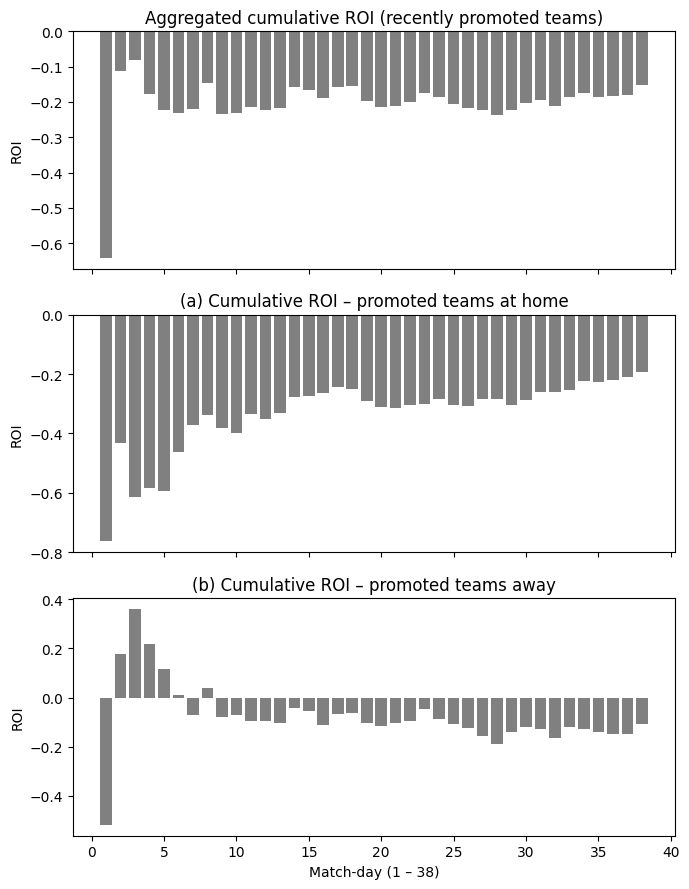

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 0. make sure Profit exists (+odds-1 if win, else -1)
if "Profit" not in bets.columns:
    bets["Profit"] = np.where(bets["Outcome"] == 1,
                              bets["Odds"] - 1,
                              -1)

# helper: cumulative ROI after each match-day (all seasons combined)
def cum_roi_by_day(subset):
    by_day = (subset
              .groupby("Matchday")["Profit"]
              .agg(total_profit="sum", bets="count")
              .sort_index())
    cum_profit = by_day["total_profit"].cumsum()
    cum_bets   = by_day["bets"].cumsum()
    return cum_profit / cum_bets            # ROI up to day k

# three betting strategies
prom_all  = bets[bets["Promoted"] == 1]
prom_home = prom_all[prom_all["IsHome"] == 1]
prom_away = prom_all[prom_all["IsHome"] == 0]

roi_all  = cum_roi_by_day(prom_all)
roi_home = cum_roi_by_day(prom_home)
roi_away = cum_roi_by_day(prom_away)

# bar-plot layout
fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)

axes[0].bar(roi_all.index,  roi_all.values,  color="grey")
axes[0].set_title("Aggregated cumulative ROI (recently promoted teams)")
axes[0].set_ylabel("ROI")

axes[1].bar(roi_home.index, roi_home.values, color="grey")
axes[1].set_title("(a) Cumulative ROI – promoted teams at home")
axes[1].set_ylabel("ROI")

axes[2].bar(roi_away.index, roi_away.values, color="grey")
axes[2].set_title("(b) Cumulative ROI – promoted teams away")
axes[2].set_xlabel("Match-day (1 – 38)")
axes[2].set_ylabel("ROI")

plt.tight_layout()
plt.show()